# Adaptive and learned sampling: train, freeze, then evaluate

Adaptive samplers and learned proposals can be exact **after training**, but only when
the fitted parameters are frozen and a fresh corrected chain is used for Monte Carlo
output. This tutorial separates four layers:

1. stochastic-approximation schedules and online covariance learning;
2. exact adaptive-MH evaluation after warmup;
3. policy objectives, including the failure of acceptance-only optimization;
4. variational and Stein approximations, with exact correction where available.

**Output semantics.** Frozen adaptive and policy-gradient MH chains are exact-invariant
Markov chains. Reverse-KL samples and SVGD particles are approximate. A learned
independence proposal becomes exact only after the full Hastings correction is applied.

In [1]:
import importlib.metadata
import os

import matplotlib.pyplot as plt
import numpy as np

from sampler_lab.adaptive import (
    FrozenPolicy,
    RobbinsMonroSchedule,
    RunningMoments,
    diminishing_ratio,
    expanding_warmup_windows,
    is_nonincreasing,
    regularize_covariance,
)
from sampler_lab.learning import diagonal_random_walk_generalized_speed_gradient
from sampler_lab.models import GaussianTarget
from sampler_lab.policy_experiments import (
    run_learning_benchmark,
    run_objective_gaming_study,
)

QUICK_MODE = os.environ.get("SAMPLER_LAB_NOTEBOOK_MODE") == "quick"
SEED = 2022
FIGURE_COUNT = 0


def finish_figure(fig):
    global FIGURE_COUNT
    fig.tight_layout()
    plt.show()
    plt.close(fig)
    FIGURE_COUNT += 1


print("sampler-lab", importlib.metadata.version("sampler-lab"))
print("execution mode:", "quick" if QUICK_MODE else "publication")
print("master seed:", SEED)

sampler-lab 0.12.0
execution mode: publication
master seed: 2022


## 1. Diminishing adaptation and explicit warmup windows

Robbins--Monro rates

$$
\eta_t = \frac{c}{(t+t_0+1)^\kappa}, \qquad \tfrac12 < \kappa \le 1,
$$

decay slowly enough that adaptation can continue, while their squared values are
summable. Expanding windows isolate initial scale learning, covariance updates, and a
final stabilization buffer. The reported chain begins only after those windows end.

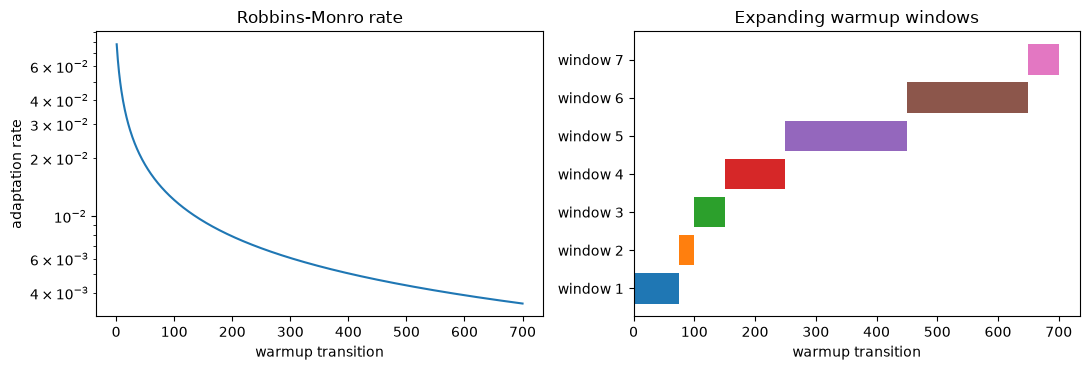

final / initial rate: 0.04513104469547915
windows: (WarmupWindow(start=0, stop=75, adapt_scale=True, adapt_covariance=False), WarmupWindow(start=75, stop=100, adapt_scale=True, adapt_covariance=True), WarmupWindow(start=100, stop=150, adapt_scale=True, adapt_covariance=True), WarmupWindow(start=150, stop=250, adapt_scale=True, adapt_covariance=True), WarmupWindow(start=250, stop=450, adapt_scale=True, adapt_covariance=True), WarmupWindow(start=450, stop=650, adapt_scale=True, adapt_covariance=True), WarmupWindow(start=650, stop=700, adapt_scale=True, adapt_covariance=False))


In [2]:
n_warmup = 220 if QUICK_MODE else 700
schedule = RobbinsMonroSchedule(initial_rate=0.25, exponent=0.65, offset=5.0)
rates = schedule.rates(n_warmup)
windows = expanding_warmup_windows(n_warmup)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(np.arange(1, n_warmup + 1), rates)
axes[0].set_yscale("log")
axes[0].set_xlabel("warmup transition")
axes[0].set_ylabel("adaptation rate")
axes[0].set_title("Robbins-Monro rate")

for index, window in enumerate(windows):
    axes[1].barh(
        index,
        window.length,
        left=window.start,
        label=("scale + covariance" if window.adapt_covariance else "scale only"),
    )
axes[1].set_xlabel("warmup transition")
axes[1].set_yticks(range(len(windows)))
axes[1].set_yticklabels([f"window {i + 1}" for i in range(len(windows))])
axes[1].set_title("Expanding warmup windows")
finish_figure(fig)

print("final / initial rate:", diminishing_ratio(rates))
print("windows:", windows)
assert is_nonincreasing(rates)
assert 0.0 < diminishing_ratio(rates) < 1.0
assert windows[-1].stop == n_warmup

## 2. Online moments and covariance repair

Welford updates learn a full covariance without retaining the complete trajectory.
Before that covariance becomes a proposal, shrinkage and eigenvalue clipping protect
against nearly singular warmup estimates. The repair is visible and quantified rather
than silently delegated to a linear-algebra backend.

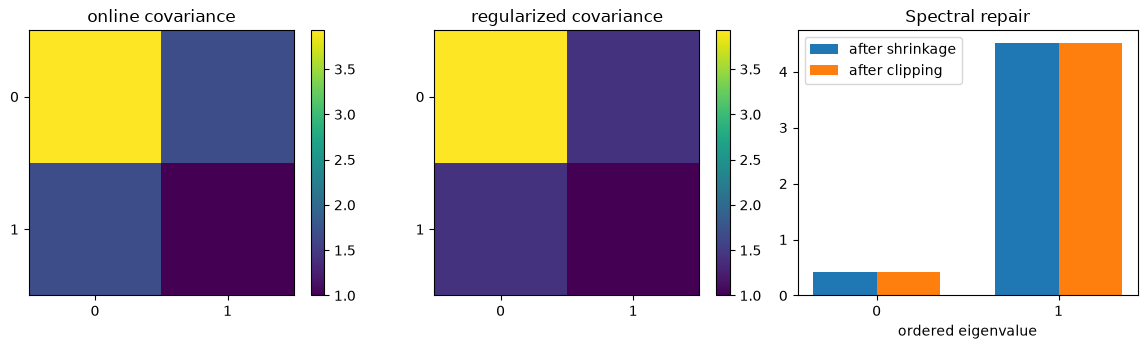

estimated mean: [ 1.01837667 -2.01169989]
correction Frobenius norm: 0.3576417131005751
frozen-policy JSON round trip: True


In [3]:
rng = np.random.default_rng(SEED)
true_mean = np.array([1.0, -2.0])
true_covariance = np.array([[4.0, 1.7], [1.7, 1.0]])
observations = rng.multivariate_normal(
    true_mean,
    true_covariance,
    size=160 if QUICK_MODE else 1_200,
)

moments = RunningMoments(2)
moments.update_batch(observations)
snapshot = moments.snapshot()
repaired = regularize_covariance(
    snapshot.covariance,
    shrinkage=0.15,
    target="diagonal",
    eigenvalue_floor=0.25,
)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for axis, matrix, title in zip(
    axes[:2],
    (snapshot.covariance, repaired.matrix),
    ("online covariance", "regularized covariance"),
    strict=True,
):
    image = axis.imshow(matrix)
    axis.set_title(title)
    axis.set_xticks([0, 1])
    axis.set_yticks([0, 1])
    fig.colorbar(image, ax=axis, fraction=0.046)
width = 0.35
axes[2].bar(
    np.arange(2) - width / 2,
    repaired.raw_eigenvalues,
    width,
    label="after shrinkage",
)
axes[2].bar(
    np.arange(2) + width / 2,
    repaired.regularized_eigenvalues,
    width,
    label="after clipping",
)
axes[2].set_xticks([0, 1])
axes[2].set_xlabel("ordered eigenvalue")
axes[2].set_title("Spectral repair")
axes[2].legend()
finish_figure(fig)

frozen = FrozenPolicy(
    "covariance-demo",
    repaired.matrix,
    {"warmup_observations": float(snapshot.count)},
)
restored = FrozenPolicy.from_json(frozen.to_json(indent=None))
print("estimated mean:", snapshot.mean)
print("correction Frobenius norm:", repaired.correction_frobenius_norm)
round_trip = np.allclose(restored.parameters, frozen.parameters.reshape(-1))
print("frozen-policy JSON round trip:", round_trip)
assert np.all(np.linalg.eigvalsh(repaired.matrix) >= 0.25 - 1e-12)
assert np.allclose(restored.parameters, frozen.parameters.reshape(-1))

## 3. Generalized speed retains a signal after rejection

Acceptance alone rewards infinitesimal proposals. The generalized-speed lower bound

$$
\min(0,\log r(x,y)) + \beta H[q_\theta(\cdot\mid x)]
$$

trades target compatibility against proposal entropy. Its pathwise derivative remains
informative even when a proposal would be rejected.

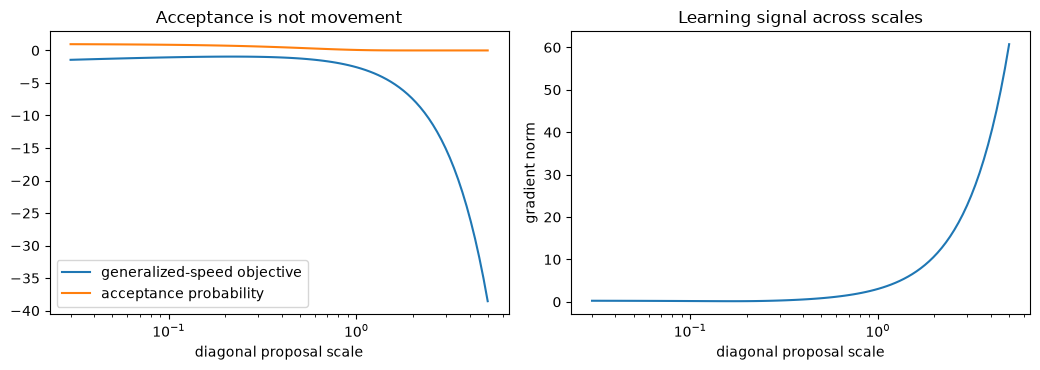

In [4]:
target = GaussianTarget(np.zeros(2), np.array([[1.0, 0.7], [0.7, 2.0]]))
current = np.array([0.5, -0.4])
noise = np.array([1.2, -0.5])
scales = np.geomspace(0.03, 5.0, 100)
evaluations = [
    diagonal_random_walk_generalized_speed_gradient(
        target,
        current,
        noise,
        np.full(2, np.log(scale)),
        beta=0.2,
    )
    for scale in scales
]
objectives = np.array([item.objective for item in evaluations])
acceptances = np.array([item.acceptance_probability for item in evaluations])
gradient_norms = np.array([np.linalg.norm(item.gradient_log_scale) for item in evaluations])

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
axes[0].plot(scales, objectives, label="generalized-speed objective")
axes[0].plot(scales, acceptances, label="acceptance probability")
axes[0].set_xscale("log")
axes[0].set_xlabel("diagonal proposal scale")
axes[0].set_title("Acceptance is not movement")
axes[0].legend()
axes[1].plot(scales, gradient_norms)
axes[1].set_xscale("log")
axes[1].set_xlabel("diagonal proposal scale")
axes[1].set_ylabel("gradient norm")
axes[1].set_title("Learning signal across scales")
finish_figure(fig)

assert np.all(np.isfinite(objectives))
assert np.all(np.isfinite(gradient_norms))
assert acceptances[0] > acceptances[-1]

## 4. Controlled failure: optimizing acceptance can destroy ESS

Three policies choose among random-walk scales. They differ only in reward:
acceptance, accepted squared jump, or a contrastive-divergence lower bound. Training
trajectories are excluded; each row below comes from a fresh chain with frozen policy
probabilities.

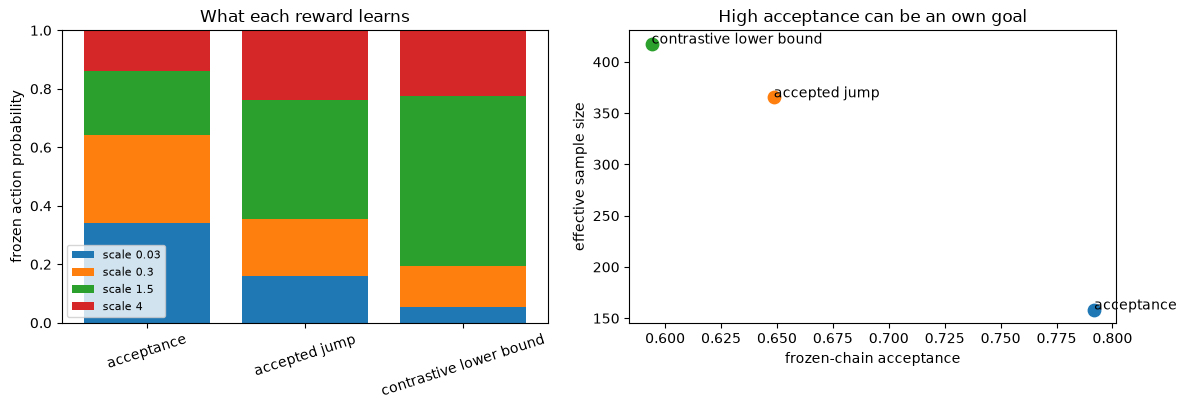

acceptance               mean scale= 0.986 acceptance= 0.792 ESS=   158.5
accepted jump            mean scale= 1.626 acceptance= 0.649 ESS=   365.4
contrastive lower bound  mean scale= 1.815 acceptance= 0.594 ESS=   417.8


In [5]:
objective_rows = run_objective_gaming_study(
    n_updates=14 if QUICK_MODE else 55,
    rollout_length=6 if QUICK_MODE else 10,
    n_evaluation_steps=700 if QUICK_MODE else 2_800,
    seed=SEED + 1,
)
action_scales = np.array([0.03, 0.3, 1.5, 4.0])
probabilities = np.array([row.action_probabilities for row in objective_rows])
labels = [row.objective for row in objective_rows]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
bottoms = np.zeros(len(objective_rows))
for action_index, scale in enumerate(action_scales):
    values = probabilities[:, action_index]
    axes[0].bar(labels, values, bottom=bottoms, label=f"scale {scale:g}")
    bottoms += values
axes[0].set_ylim(0.0, 1.0)
axes[0].set_ylabel("frozen action probability")
axes[0].set_title("What each reward learns")
axes[0].tick_params(axis="x", rotation=18)
axes[0].legend(fontsize=8)

for row in objective_rows:
    axes[1].scatter(row.acceptance_rate, row.effective_sample_size, s=80)
    axes[1].annotate(row.objective, (row.acceptance_rate, row.effective_sample_size))
axes[1].set_xlabel("frozen-chain acceptance")
axes[1].set_ylabel("effective sample size")
axes[1].set_title("High acceptance can be an own goal")
finish_figure(fig)

for row in objective_rows:
    print(
        f"{row.objective:24s} mean scale={row.mean_scale:6.3f} "
        f"acceptance={row.acceptance_rate:6.3f} ESS={row.effective_sample_size:8.1f}"
    )
assert np.allclose(np.sum(probabilities, axis=1), 1.0)
assert all(row.effective_sample_size > 0.0 for row in objective_rows)

## 5. Exact-after-freeze and approximate methods need different labels

The separated-mixture laboratory compares a direct oracle, local and adaptive MH,
policy-gradient MH, reverse-KL approximation, exact independence-MH correction, and
SVGD particles. Moment and MMD errors measure distributional accuracy; chain IAT is not
assigned to deterministic particle output. Reverse KL may choose one mode, while exact
correction preserves the target but can still mix badly when overlap is poor.

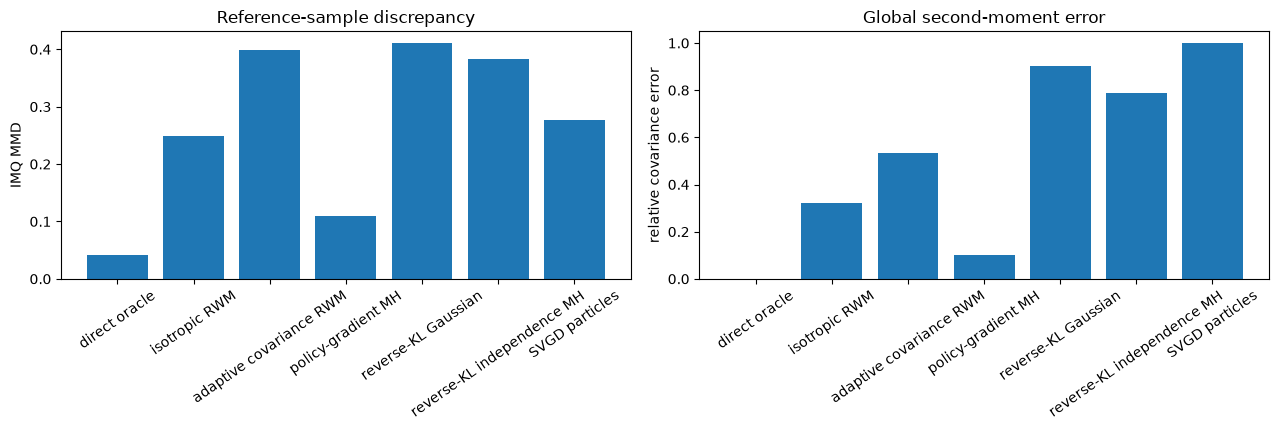

direct oracle                exact_after_freeze=True  semantics=unweighted-samples       MMD=0.04192686136164721
isotropic RWM                exact_after_freeze=True  semantics=unweighted-samples       MMD=0.24863999997988867
adaptive covariance RWM      exact_after_freeze=True  semantics=unweighted-samples       MMD=0.3990250923472772
policy-gradient MH           exact_after_freeze=True  semantics=unweighted-samples       MMD=0.10911389349240479
reverse-KL Gaussian          exact_after_freeze=False semantics=unweighted-samples       MMD=0.4107793575059182
reverse-KL independence MH   exact_after_freeze=True  semantics=unweighted-samples       MMD=0.3827678870959626
SVGD particles               exact_after_freeze=False semantics=unweighted-samples       MMD=0.27760497871481815


In [6]:
benchmark_rows = run_learning_benchmark(
    n_samples=420 if QUICK_MODE else 1_600,
    n_warmup=160 if QUICK_MODE else 650,
    policy_updates=10 if QUICK_MODE else 40,
    variational_steps=20 if QUICK_MODE else 80,
    svgd_particles=40 if QUICK_MODE else 96,
    svgd_steps=8 if QUICK_MODE else 25,
    seed=SEED + 2,
)
methods = [row.method for row in benchmark_rows]
mmd = np.array(
    [
        np.nan if row.distribution.imq_mmd is None else row.distribution.imq_mmd
        for row in benchmark_rows
    ]
)
covariance_error = np.array([row.distribution.relative_covariance_error for row in benchmark_rows])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].bar(methods, mmd)
axes[0].set_ylabel("IMQ MMD")
axes[0].set_title("Reference-sample discrepancy")
axes[1].bar(methods, covariance_error)
axes[1].set_ylabel("relative covariance error")
axes[1].set_title("Global second-moment error")
for axis in axes:
    axis.tick_params(axis="x", rotation=35)
finish_figure(fig)

for row in benchmark_rows:
    print(
        f"{row.method:28s} exact_after_freeze={row.exact_after_freeze!s:5s} "
        f"semantics={row.output_semantics:24s} "
        f"MMD={row.distribution.imq_mmd}"
    )
assert any(row.exact_after_freeze for row in benchmark_rows)
assert any(not row.exact_after_freeze for row in benchmark_rows)
assert np.all(np.isfinite(covariance_error))

## Takeaways

- Adaptation belongs to warmup; evaluation starts from a frozen policy and a fresh RNG.
- Covariance estimates need visible regularization, not hopeful Cholesky calls.
- Acceptance is a constraint or diagnostic, not a universal learning objective.
- Exact correction fixes stationary bias, not poor overlap or slow mode switching.
- Variational and Stein outputs are useful approximations, but they should not be
  mislabeled as stationary Markov-chain samples.

In [7]:
assert FIGURE_COUNT >= 5
print("figures rendered:", FIGURE_COUNT)

figures rendered: 5
